<a href="https://colab.research.google.com/github/springboardmentor443m-coder/AI-Skin-Intelligence-Personalized-Skincare-Planner/blob/Subhransu-Sekhar/Recommendation_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
# Main dataset
# Simple upload
uploaded = files.upload()

# Load the csv
raw_df = pd.read_csv('product_info.csv')
print(f"Dataset loaded successfully. Shape: {raw_df.shape}")
display(raw_df.head())

Saving product_info.csv to product_info.csv
Dataset loaded successfully. Shape: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [ ]:
import re
import ast
import pandas as pd
from google.colab import files

# Load original raw data
raw_df = pd.read_csv('product_info.csv')

def final_precision_parser(highlight_str):
    if not highlight_str or pd.isna(highlight_str) or highlight_str == '':
        return "Universal", "General Care"
    try:
        tags = ast.literal_eval(highlight_str) if isinstance(highlight_str, str) else highlight_str
        tags = [str(t).lower().strip() for t in tags]
    except:
        return "Universal", "General Care"

    found_types = set()
    found_concerns = set()

    type_keywords = {'oily': 'Oily', 'dry': 'Dry', 'normal': 'Normal', 'combination': 'Combination', 'combo': 'Combination'}

   # UPDATED MAPPING BASED ON USER REQUEST
    greedy_map = {
        'acne': 'Acne/Blemishes', 'blemish': 'Acne/Blemishes', 'breakout': 'Acne/Blemishes',
        'loss of firmness': 'Firmness/Elasticity', 'firmness': 'Firmness/Elasticity', 'elasticity': 'Firmness/Elasticity',
        'collagen': 'Collagen/Plumping', 'plumping': 'Collagen/Plumping', 'hyaluronic': 'Hydration/Dryness',
        'fine lines': 'Fine Lines/Wrinkles', 'wrinkles': 'Fine Lines/Wrinkles',
        'anti-aging': 'Anti-Aging', 'aging': 'Anti-Aging', 'rejuvenating': 'Anti-Aging',
        'dark spots': 'Dark Spots', 'hyperpigmentation': 'Dark Spots', 'brightening': 'Brightening',
        'pores': 'Pores', 'blackheads': 'Pores',
        'redness': 'Redness', 'soothing': 'Redness', 'irritation': 'Redness', 'inflammation': 'Redness',
        'dullness': 'Dullness/Texture', 'uneven texture': 'Dullness/Texture', 'texture': 'Dullness/Texture',
        'dryness': 'Hydration/Dryness', 'hydrating': 'Hydration/Dryness', 'dehydration': 'Hydration/Dryness',
        'hypoallergenic': 'Hypoallergenic', 'sensitive': 'Sensitivity', 'eczema': 'Eczema',
        'spf': 'Sun Protection', 'uv protection': 'Sun Protection', 'vitamin c': 'Brightening',
        'dark circles': 'Dark Circles', 'puffiness': 'Puffiness', 'under-eye': 'Eye Care'
    }

    for tag in tags:
        if 'best for' in tag:
            for k, v in type_keywords.items():
                if k in tag: found_types.add(v)

        for k, v in greedy_map.items():
            if k in tag:
                found_concerns.add(v)

    res_type = ", ".join(sorted(found_types)) if found_types else "Universal"
    res_concern = ", ".join(sorted(found_concerns)) if found_concerns else "General Care"
    return res_type, res_concern

# --- Pipeline Execution v12 (Corrected Cleaning) ---
skincare_v13 = raw_df[raw_df['primary_category'] == 'Skincare'].copy()
skincare_v13 = skincare_v13.dropna(subset=['ingredients']).reset_index(drop=True)

for col in ['highlights', 'ingredients', 'secondary_category', 'tertiary_category', 'brand_name', 'product_name']:
    skincare_v13[col] = skincare_v13[col].fillna('')

skincare_v13[['skin_types', 'skin_concerns']] = skincare_v13['highlights'].apply(lambda x: pd.Series(final_precision_parser(x)))

def final_clean_ingredients(text):
    text = str(text).lower()
    # Normalize slashes
    text = text.replace('\\', '/').replace('//', '/')
    while '//' in text: text = text.replace('//', '/')
    # Remove brackets, trademarks, and line breaks
    text = re.sub(r"[\[\]\*™®©\r\n]", " ", text)
    # Remove various quote styles
    text = re.sub(r"['\"\‘\’\“\”]", "", text)
    return re.sub(r"\s+", " ", text).strip()

skincare_v13['ingredients_cleaned'] = skincare_v13['ingredients'].apply(final_clean_ingredients)
#skincare_v13['product_type'] = (skincare_v13['secondary_category'] + ' ' + skincare_v13['tertiary_category']).str.strip()
skincare_v13['price'] = skincare_v13['price_usd'].fillna(skincare_v13.get('child_min_price', 0)).astype(float)
# LOGICAL PRODUCT CATEGORY MERGING
def consolidate_category(row):
    sec = str(row['secondary_category']).strip()
    tert = str(row['tertiary_category']).strip()
    if sec == tert or tert == "" or tert == "nan": combined = sec
    elif sec in tert: combined = tert
    else: combined = f"{sec} {tert}"

    mapping = {
    # --- Cleansers (removal of dirt/oil/makeup, pH-balancing) ---
    'Cleansers Face Wash & Cleansers': 'Cleansers',
    'Cleansers Toners': 'Cleansers',
    'Cleansers Exfoliators': 'Cleansers',
    'Cleansers Makeup Removers': 'Cleansers',
    'Cleansers Face Wipes': 'Cleansers',
    'Cleansers Blotting Papers': 'Cleansers',
    'Cleansers': 'Cleansers',

    # --- Moisturizers (occlusive/humectant hydration & barrier support) ---
    'Moisturizers Moisturizers': 'Moisturizers',
    'Moisturizers Mists & Essences': 'Moisturizers',
    'Moisturizers Face Oils': 'Moisturizers',
    'Moisturizers Night Creams': 'Moisturizers',
    'Moisturizers Decollete & Neck Creams': 'Moisturizers',
    'Moisturizers BB & CC Creams': 'Moisturizers',   # tinted moisturizer, not "treatment"
    'Moisturizers': 'Moisturizers',

    # --- Treatments (active-ingredient, concern-targeted, higher concentration) ---
    'Treatments Face Serums': 'Treatments/Serums',
    'Treatments Facial Peels': 'Treatments/Serums',
    'Treatments Blemish & Acne Treatments': 'Treatments/Serums',
    'Shop by Concern Anti-Aging': 'Treatments/Serums',  # concern-tag, not a format — maps to function

    # --- Masks (short-contact-time, occlusive/active treatments) ---
    'Masks Face Masks': 'Masks',
    'Masks Sheet Masks': 'Masks',

    # --- Eye Care (thinner skin, distinct formulation needs) ---
    'Eye Care Eye Creams & Treatments': 'Eye Care',
    'Eye Care Eye Masks': 'Eye Care',

    # --- Sun Care (UV protection — distinct regulatory/medical category, OTC drug in many regions) ---
    'Sunscreen Face Sunscreen': 'Sun Care',
    'Sunscreen Body Sunscreen': 'Sun Care',
    'Sunscreen': 'Sun Care',

    # --- Lip Care ---
    'Lip Balms & Treatments': 'Lip Care',

    # --- Self Tanners (cosmetic pigmentation via DHA, not a "treatment" in the medical sense) ---
    'Self Tanners For Body': 'Self Tanners',
    'Self Tanners For Face': 'Self Tanners',
    'Self Tanners': 'Self Tanners',

    # --- Wellness (ingestible / holistic — different route of administration than topical) ---
    'Wellness Beauty Supplements': 'Wellness',
    'Wellness Holistic Wellness': 'Wellness',

    # --- Devices & Tools (mechanical/electronic, not chemical/topical action) ---
    'High Tech Tools Anti-Aging': 'Devices & Tools',
    'High Tech Tools Teeth Whitening': 'Devices & Tools',
    'Wellness Facial Rollers': 'Devices & Tools',   # mechanical massage tool, not ingestible wellness

    # --- Kits & Minis (packaging format, not a function/concern) ---
    'Value & Gift Sets': 'Kits & Minis',
    'Mini Size': 'Kits & Minis',
}
    return mapping.get(combined, combined)

skincare_v13['product_type'] = skincare_v13.apply(consolidate_category, axis=1)
for col in ['loves_count', 'rating', 'reviews']:
    skincare_v13[col] = pd.to_numeric(skincare_v13[col], errors='coerce').fillna(0)
    mx, mn = skincare_v13[col].max(), skincare_v13[col].min()
    skincare_v13[f'{col}_norm'] = (skincare_v13[col] - mn) / (mx - mn) if mx > mn else 0

final_cols = ['product_id', 'brand_name', 'product_name', 'price', 'product_type', 'loves_count_norm', 'rating_norm', 'reviews_norm', 'skin_types', 'skin_concerns', 'ingredients_cleaned']
output_v13 = 'final_skincare_v13_complete.csv'
skincare_v13[final_cols].to_csv(output_v13, index=False)

print(f"Corrected Pipeline v13 complete. Total: {len(skincare_v13)} products.")
display(skincare_v13[final_cols].head(5))
#files.download(output_v13)

Corrected Pipeline v13 complete. Total: 2286 products.


,product_id,brand_name,product_name,price,product_type,loves_count_norm,rating_norm,reviews_norm,skin_types,skin_concerns,ingredients_cleaned
0,P439055,Algenist,GENIUS Sleeping Collagen Moisturizer,98.0,Moisturizers,0.031360,0.90826,0.081958,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), ethylhex..."
1,P421277,Algenist,GENIUS Liquid Collagen Serum,115.0,Treatments/Serums,0.062766,0.80518,0.071907,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), propaned..."
2,P467602,Algenist,Triple Algae Eye Renewal Balm Eye Cream,68.0,Eye Care,0.016545,0.90612,0.070852,Universal,General Care,"aqua (water/eau), stearic acid, isopropyl isos..."
3,P432045,Algenist,GENIUS Liquid Collagen Lip Treatment,29.0,Lip Care,0.041106,0.77442,0.040266,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), glycerin..."
4,P311143,Algenist,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,28.0,Face Sunscreen,0.025227,0.88268,0.031518,"Combination, Dry, Normal","Hypoallergenic, Sun Protection","octinoxate 7.5%, titanium dioxide 2%, zinc oxi..."


### **Google Drive Auto-Load Setup**
Mounting your Drive allows you to store the `v13` dataset permanently so you don't have to upload it every session.

In [ ]:
from google.colab import drive, files
import os
import shutil
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the permanent storage path
drive_folder = '/content/drive/My Drive/skincare_data/'
file_name = 'final_skincare_v13_complete.csv'
full_drive_path = os.path.join(drive_folder, file_name)

# Create folder if it doesn't exist
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

# 3. Check if file exists in Drive, otherwise handle initial upload
if os.path.exists(full_drive_path):
    print(f"✅ Loading dataset from Google Drive: {full_drive_path}")
    df_v13 = pd.read_csv(full_drive_path)
else:
    print("⚠️ File not found in Drive. Let's fix this for you permanently.")
    # Check if user already uploaded it to the local session
    if not os.path.exists(file_name):
        print("Please upload 'final_skincare_v13_complete.csv' below one last time:")
        uploaded = files.upload()

    # Save to Drive for future sessions
    if os.path.exists(file_name):
        print(f"💾 Saving {file_name} to Google Drive for permanent access...")
        shutil.copy(file_name, full_drive_path)
        df_v13 = pd.read_csv(full_drive_path)
        print("✅ Done! From now on, you won't need to upload this file anymore.")
    else:
        print("❌ Upload failed. Please make sure the file name is correct.")

# Display the loaded data to confirm
print(f"Dataset ready with {len(df_v13)} products.")
display(df_v13.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loading dataset from Google Drive: /content/drive/My Drive/skincare_data/final_skincare_v13_complete.csv
Dataset ready with 2286 products.


,product_id,brand_name,product_name,price,product_type,loves_count_norm,rating_norm,reviews_norm,skin_types,skin_concerns,ingredients_cleaned
0,P439055,Algenist,GENIUS Sleeping Collagen Moisturizer,98.0,Moisturizers,0.031360,0.90826,0.081958,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), ethylhex..."
1,P421277,Algenist,GENIUS Liquid Collagen Serum,115.0,Treatments/Serums,0.062766,0.80518,0.071907,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), propaned..."
2,P467602,Algenist,Triple Algae Eye Renewal Balm Eye Cream,68.0,Eye Care,0.016545,0.90612,0.070852,Universal,General Care,"aqua (water/eau), stearic acid, isopropyl isos..."
3,P432045,Algenist,GENIUS Liquid Collagen Lip Treatment,29.0,Lip Care,0.041106,0.77442,0.040266,"Combination, Dry, Normal","Collagen/Plumping, Firmness/Elasticity, Hypoal...","collagen (vegan) , water (aqua, eau), glycerin..."
4,P311143,Algenist,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,28.0,Face Sunscreen,0.025227,0.88268,0.031518,"Combination, Dry, Normal","Hypoallergenic, Sun Protection","octinoxate 7.5%, titanium dioxide 2%, zinc oxi..."


In [ ]:
import pandas as pd

# Using the already loaded df_v13 from previous steps
# Calculate totals
total_concerns = df_v13['skin_concerns'].str.split(', ').explode().nunique()
total_types = df_v13['product_type'].nunique()

print(f"--- Dataset Summary Statistics ---")
print(f"Total Unique Skin Concerns identified: {total_concerns}")
print(f"Total Unique Product Types identified: {total_types}")
print(f"Total Products in Engine: {len(df_v13)}")

# 1. Calculate frequency of each Concern
concerns_series = df_v13['skin_concerns'].str.split(', ').explode().value_counts().reset_index()
concerns_series.columns = ['Skin Concern', 'Count']

# 2. Calculate frequency of each Product Type
type_series = df_v13['product_type'].value_counts().reset_index()
type_series.columns = ['Product Type', 'Count']

print("--- Skin Concern Distribution ---")
display(concerns_series)

print("\n--- Product Type Distribution ---")
display(type_series)

--- Dataset Summary Statistics ---
Total Unique Skin Concerns identified: 14
Total Unique Product Types identified: 17
Total Products in Engine: 2286
--- Skin Concern Distribution ---


,Skin Concern,Count
0,Hydration/Dryness,981
1,Dullness/Texture,720
2,Anti-Aging,552
3,General Care,501
4,Firmness/Elasticity,367
5,Pores,315
6,Brightening,214
7,Dark Circles,199
8,Acne/Blemishes,187
9,Dark Spots,160



--- Product Type Distribution ---


,Product Type,Count
0,Moisturizers,539
1,Treatments/Serums,427
2,Kits & Minis,298
3,Face Wash & Cleansers,215
4,Eye Care,184
5,Cleansers,139
6,Face Masks,131
7,Face Sunscreen,93
8,Lip Care,60
9,Self Tanners,48


In [ ]:
#"Count only those products whose entire skin concern list is exactly Hydration/Dryness and nothing else."
df = pd.read_csv('final_skincare_v13_complete.csv')

split = df["skin_concerns"].str.split(", ")

only_hd = split.apply(lambda x: set(x) == {"Hydration/Dryness"})


print("Only Hydration/Dryness:", only_hd.sum())


Only Hydration/Dryness: 198


# **EDA ANALYSIS**

Dataset Shape: (2286, 11)
Missing Ingredients Count: 0


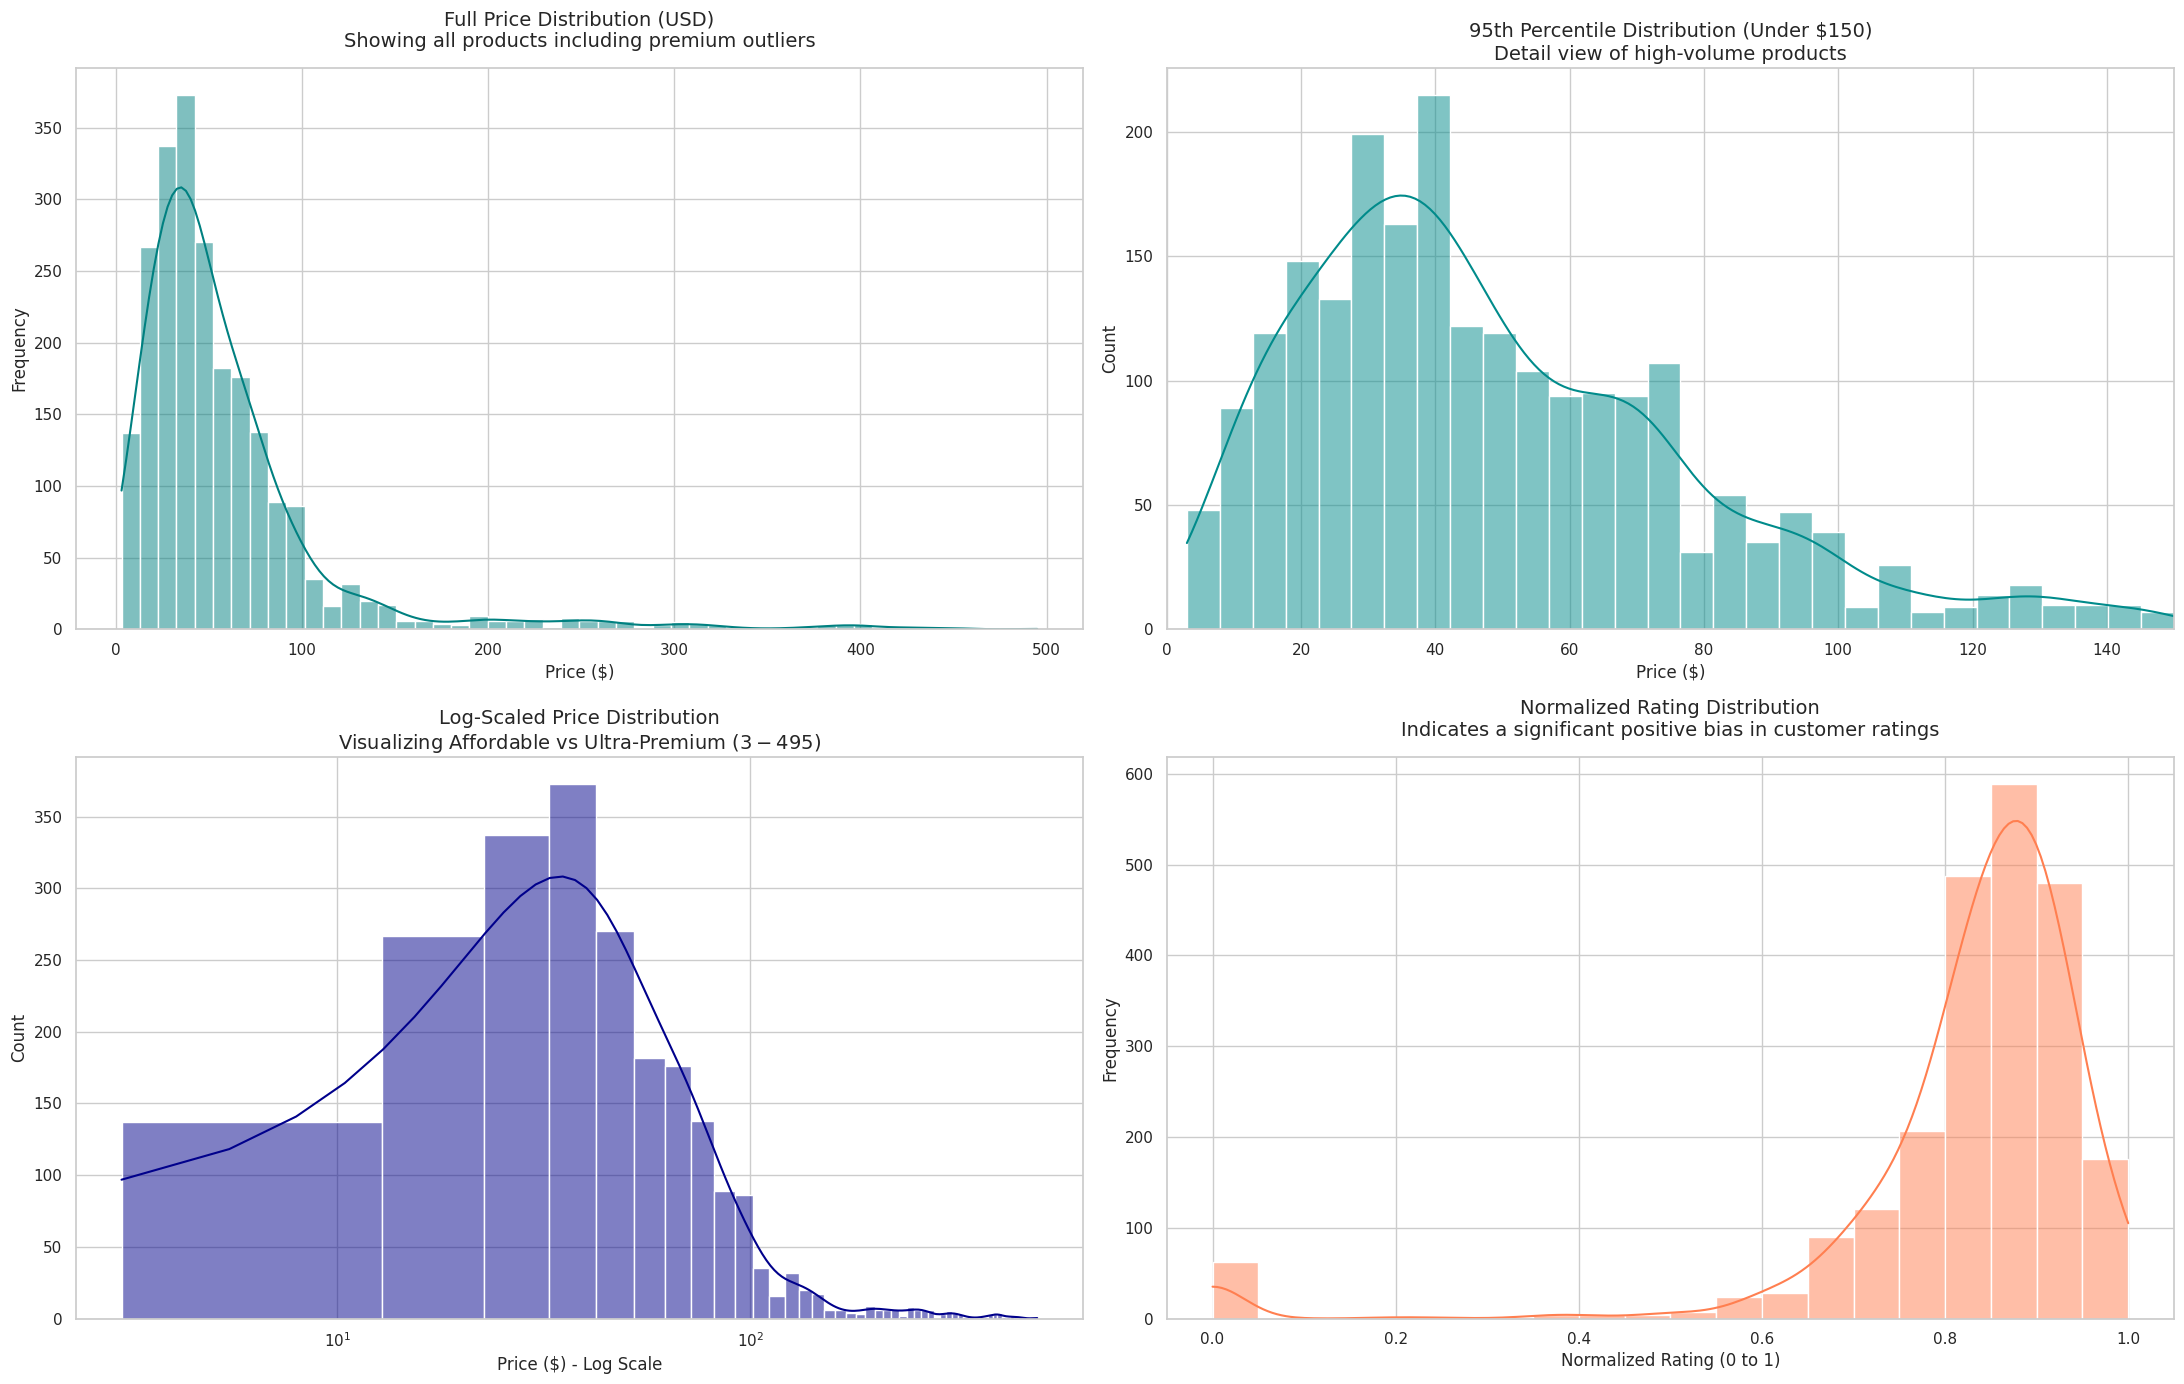

--- Price Analysis ---
The Log scale reveals the bi-modal peak around $44.0, while the 95th percentile clip eliminates the extreme tail (max $495.0) to focus on the core market density.


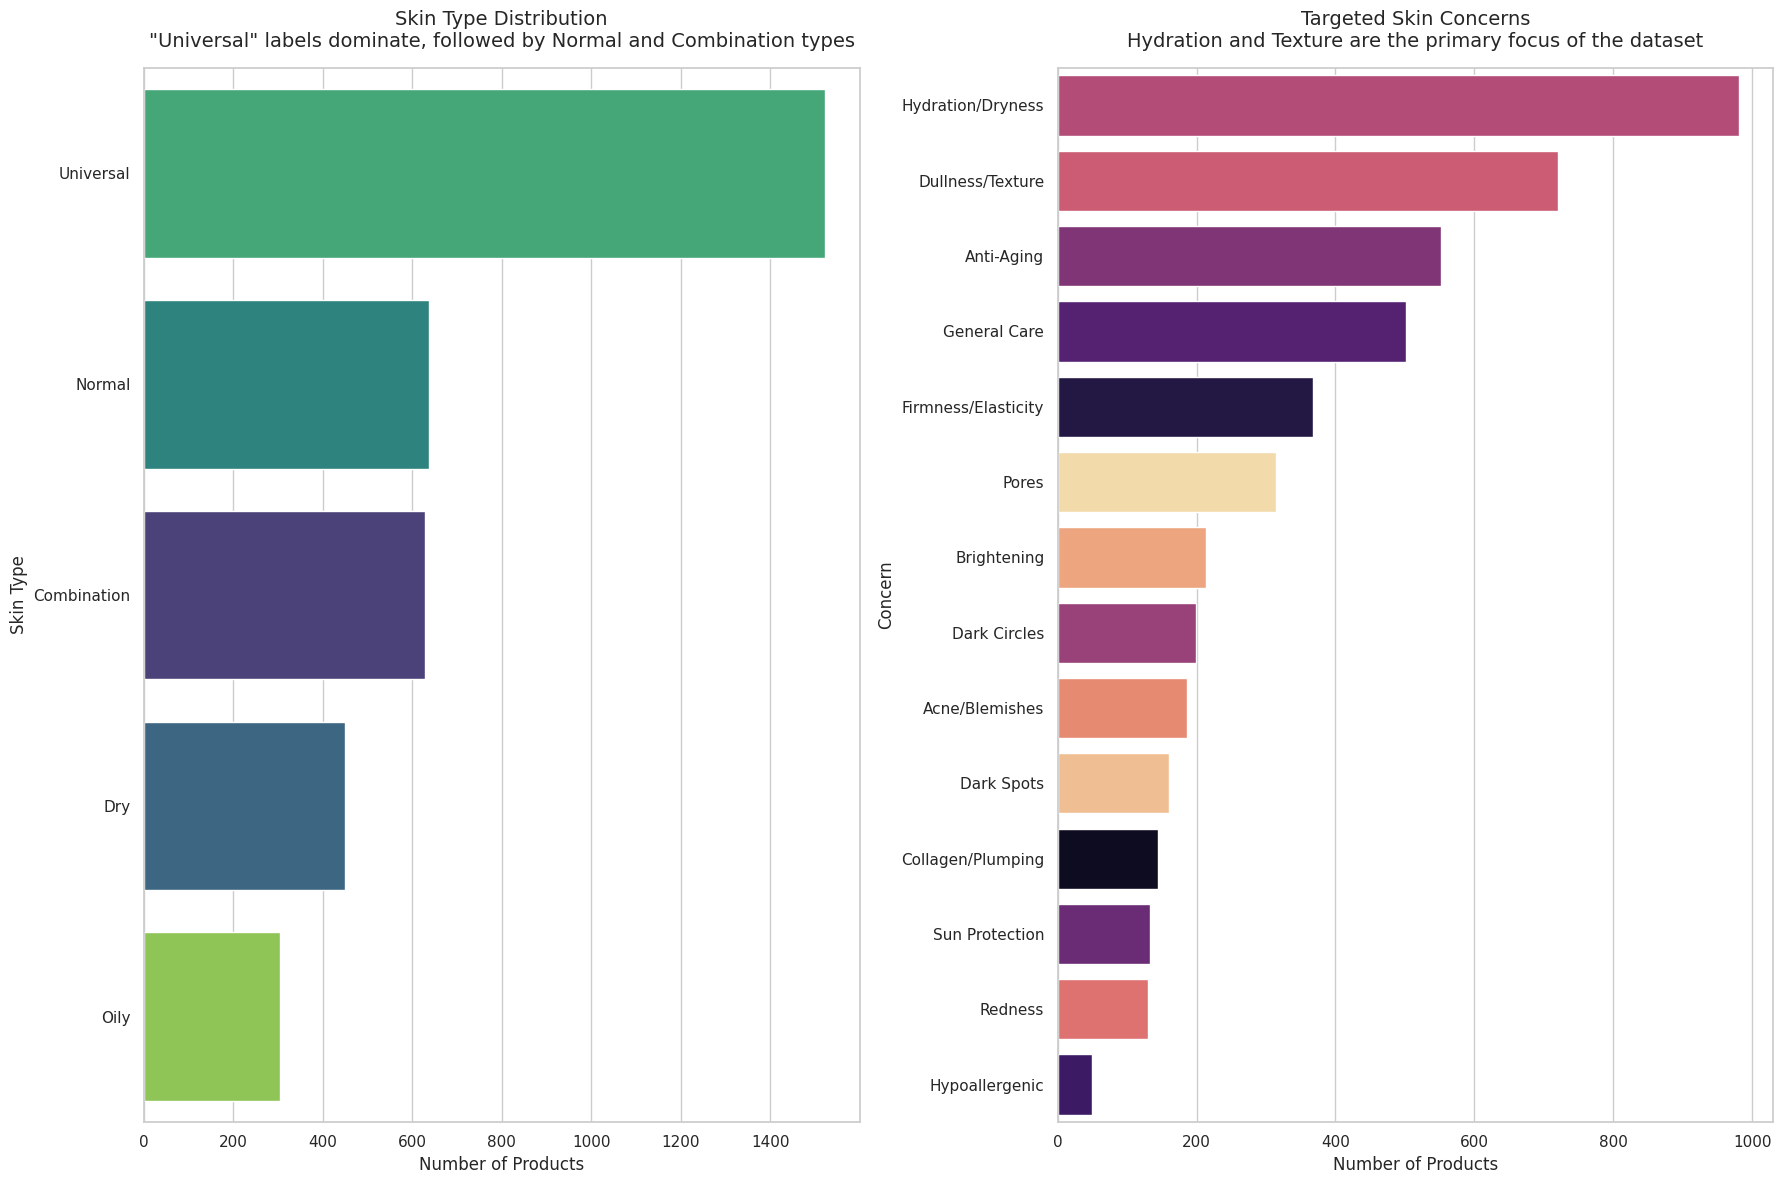

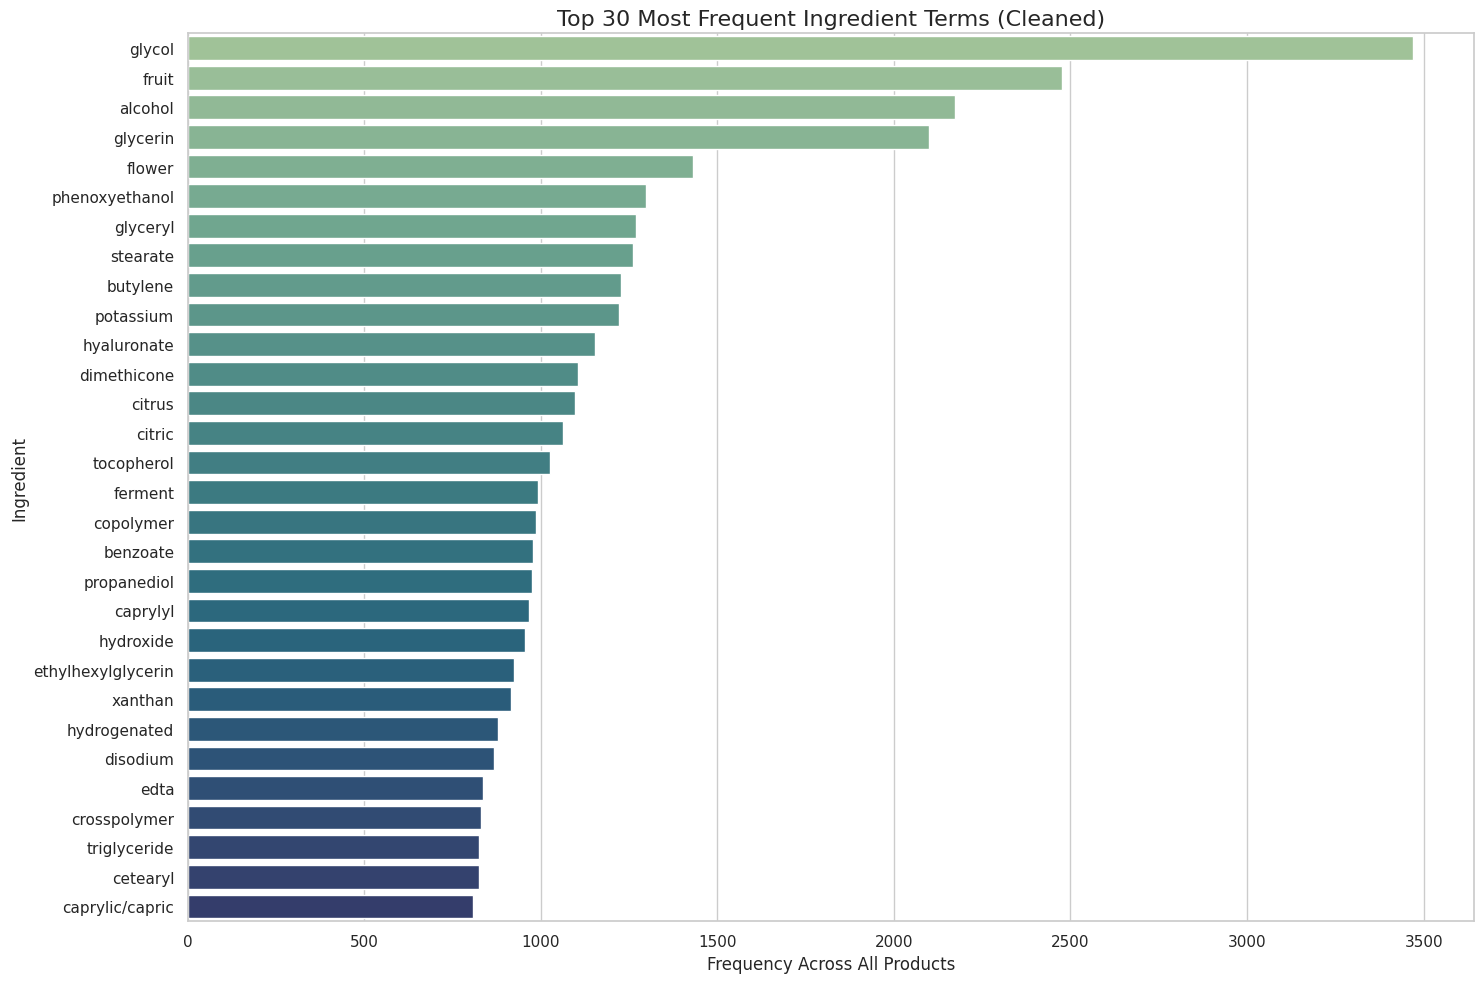

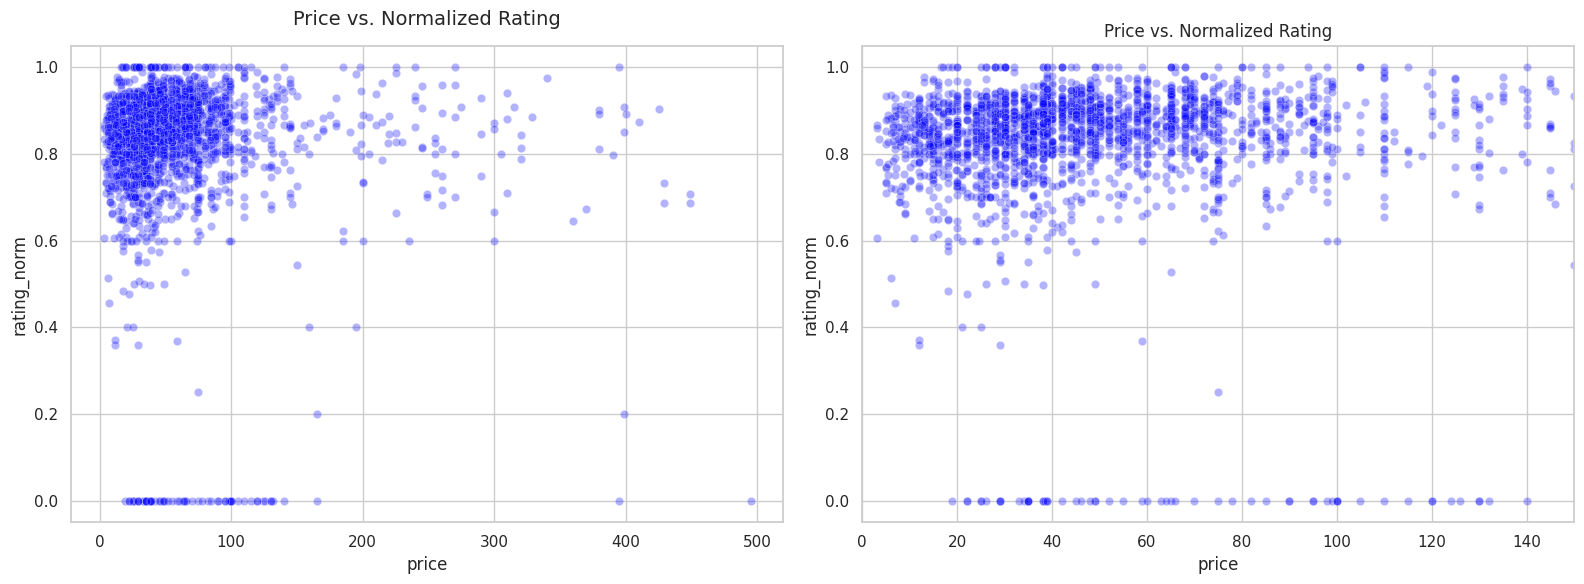

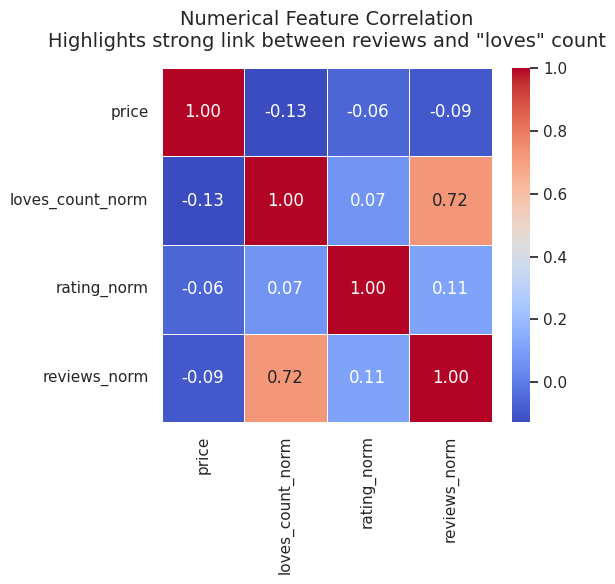

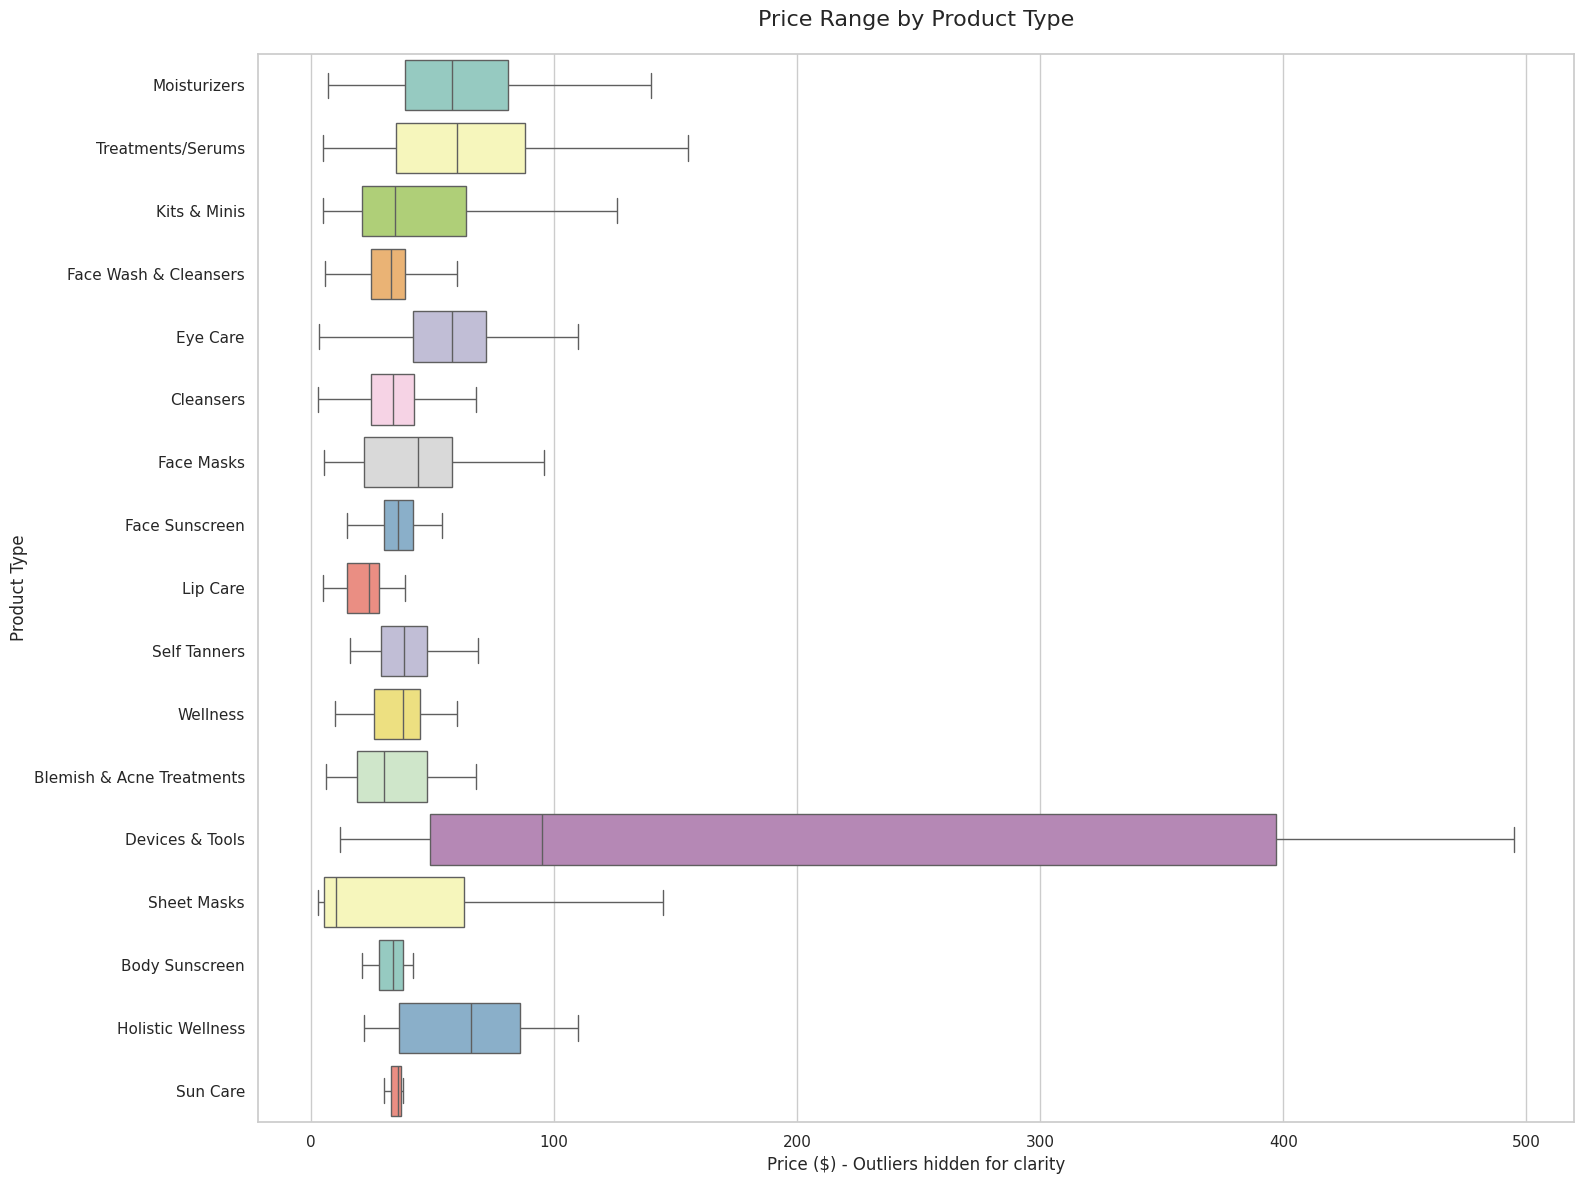

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Load the custom cleaned dataset
df = pd.read_csv('final_skincare_v13_complete.csv')

# Set up the visual style
sns.set_theme(style="whitegrid")

print(f"Dataset Shape: {df.shape}")
print("Missing Ingredients Count:", df['ingredients_cleaned'].isna().sum())

# ==========================================
# PART 1: UNIVARIATE ANALYSIS (Price & Rating)
# ==========================================
#fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# 2x2 layout to show all requested perspectives side-by-side
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# 1A. Price Distribution - MODIFIED TO SHOW FULL RANGE
sns.histplot(df['price'], bins=50, kde=True, color='teal', ax=axes[0,0])
axes[0,0].set_title('Full Price Distribution (USD)\nShowing all products including premium outliers', fontsize=14, pad=15)
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Frequency')
# axes[0].set_xlim(0, df['price'].quantile(0.95)) # Removed to show full graph

# 1B. 95th Percentile Price Distribution (Clipping logic applied)
p95 = df['price'].quantile(0.95)
sns.histplot(df[df['price'] <= p95]['price'], bins=30, kde=True, color='darkcyan', ax=axes[0, 1])
axes[0, 1].set_title(f'95th Percentile Distribution (Under ${p95:.0f})\nDetail view of high-volume products', fontsize=14)
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_xlim(0, p95)



# 1C. Price Distribution with Log Scale
sns.histplot(df['price'], bins=50, kde=True, color='darkblue', ax=axes[1, 0])
axes[1, 0].set_title('Log-Scaled Price Distribution\nVisualizing Affordable vs Ultra-Premium ($3 - $495)', fontsize=14)
axes[1, 0].set_xlabel('Price ($) - Log Scale')
axes[1, 0].set_xscale('log')

# 1D. Rating Skew
sns.histplot(df['rating_norm'], bins=20, kde=True, color='coral', ax=axes[1,1])
axes[1,1].set_title('Normalized Rating Distribution\nIndicates a significant positive bias in customer ratings', fontsize=14, pad=15)
axes[1,1].set_xlabel('Normalized Rating (0 to 1)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Quick Analysis
print(f"--- Price Analysis ---")
print(f"The Log scale reveals the bi-modal peak around ${df['price'].median()}, while the 95th percentile clip eliminates the extreme tail (max ${df['price'].max()}) to focus on the core market density.")


# ==========================================
# PART 2: CATEGORICAL ANALYSIS (Skin Types & ALL Concerns)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# 2A. Plot Skin Type Distribution
skin_types_split = df['skin_types'].str.split(', ').explode().reset_index(drop=True)
sns.countplot(y=skin_types_split, order=skin_types_split.value_counts().index, ax=axes[0], hue=skin_types_split, palette="viridis", legend=False)
axes[0].set_title('Skin Type Distribution\n"Universal" labels dominate, followed by Normal and Combination types', fontsize=14, pad=15)
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Skin Type')

# 2B. Plot ALL Skin Concerns Distribution
concerns_split = df['skin_concerns'].str.split(', ').explode().reset_index(drop=True)
sns.countplot(y=concerns_split, order=concerns_split.value_counts().index, ax=axes[1], hue=concerns_split, palette="magma", legend=False)
axes[1].set_title('Targeted Skin Concerns\nHydration and Texture are the primary focus of the dataset', fontsize=14, pad=15)
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Concern')

plt.tight_layout()
plt.show()

# ==========================================
# PART 3: INGREDIENT FREQUENCY ANALYSIS
# ==========================================

all_ingredients = ' '.join(df['ingredients_cleaned'].astype(str)).replace(',', ' ').lower().split()
stop_words = {'and', 'or', 'extract', 'oil', 'acid', 'sodium', 'seed', 'leaf', 'root', 'water', 'aqua', 'eau'}
filtered_ingredients = [word.strip() for word in all_ingredients if len(word) > 3 and word not in stop_words]

ingredient_counts = Counter(filtered_ingredients)
top_ingredients = pd.DataFrame(ingredient_counts.most_common(30), columns=['Ingredient', 'Count'])

plt.figure(figsize=(15, 10))
sns.barplot(data=top_ingredients, x='Count', y='Ingredient', hue='Ingredient', palette="crest", legend=False)
plt.title('Top 30 Most Frequent Ingredient Terms (Cleaned)', fontsize=16)
plt.xlabel('Frequency Across All Products')
plt.tight_layout()
plt.show()
# ==========================================
# PART 4: BIVARIATE & MULTIVARIATE ANALYSIS
# ==========================================
fig, axes = plt.subplots(1,2, figsize=(16, 6))

# 4A. Price vs. Rating
sns.scatterplot(data=df, x='price', y='rating_norm', alpha=0.3, color='blue', ax=axes[0])
axes[0].set_title('Price vs. Normalized Rating', fontsize=14, pad=15)

# 4B. Price vs. Rating
sns.scatterplot(data=df, x='price', y='rating_norm', alpha=0.3, color='blue', ax=axes[1])
axes[1].set_title('Price vs. Normalized Rating')
axes[1].set_xlim(0, df['price'].quantile(0.95))

plt.tight_layout()
plt.show()
# 4C. Multivariate Correlation Heatmap
fig, ax = plt.subplots(1,1, figsize=(6, 6))
numerical_cols = ['price', 'loves_count_norm', 'rating_norm', 'reviews_norm']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Numerical Feature Correlation\nHighlights strong link between reviews and "loves" count', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

# ==========================================
# PART 5: PRICE VS. PRODUCT TYPE (BOXPLOT)
# ==========================================
plt.figure(figsize=(16, 12))
type_order = df['product_type'].value_counts().index

sns.boxplot(
    data=df,
    x='price',
    y='product_type',
    order=type_order,
    hue='product_type',
    palette='Set3',
    showfliers=False,
    legend=False
)

plt.title('Price Range by Product Type', fontsize=16, pad=20)
plt.xlabel('Price ($) - Outliers hidden for clarity')
plt.ylabel('Product Type')
plt.tight_layout()
plt.show()

### **Executive Summary of Exploratory Data Analysis (EDA)**

Based on the visualizations generated above, here are the key insights from the skincare dataset:

#### **1. Price Analysis**
*   **Full Range & Outliers:** The dataset spans a wide range from budget-friendly items (3) to ultra-premium luxury products (up to 495). The median price sits around 44.
*   **Market Density:** The 95th percentile clipping at 150 reveals that the vast majority of products are concentrated in the 20–60 range, representing the high-volume core of the market.
*   **Log-Scale Insight:** The log-scaled distribution highlights a bi-modal trend, suggesting two distinct market segments: affordable everyday skincare and prestige treatments.

#### **2. Customer Sentiment (Ratings & Engagement)**
*   **Positive Bias:** The **Normalized Rating Distribution** is heavily skewed toward the right (0.8–0.9), indicating a strong positive bias in customer reviews. Very few products receive poor ratings.
*   **Engagement Correlation:** The heatmap shows a strong positive correlation between **Review Count** and **Loves Count**, suggesting that popular products (by sales/mentions) are also the most frequently discussed and saved by users.

#### **3. Product Categorization & Concerns**
*   **Category Leaders:** **Moisturizers** and **Treatments/Serums** are the most prevalent product types, followed by Kits & Minis.
*   **Primary Concerns:** **Hydration/Dryness** is the most targeted skin concern by far (nearly 1,000 products), followed by **Dullness/Texture** and **Anti-Aging**. This indicates a market focus on moisture and skin barrier health.
*   **Skin Types:** "Universal" labels are the most common, followed by Normal and Combination types, showing a trend toward products marketed as safe for everyone.

#### **4. Ingredient Composition**
*   **Chemical vs. Natural:** The most frequent ingredient terms are **Glycols** (solvents/humectants) and **Glycerin**, which aligns with the high frequency of Hydration-focused products.
*   **Botanicals:** "Fruit" and "Flower" terms appear very frequently, reflecting the industry's heavy use of plant-derived extracts for marketing and antioxidant properties.

#### **5. Price vs. Product Type**
*   **Premium Categories:** Treatments, Serums, and Eye Care tend to have higher median prices and broader price ranges compared to Cleansers and Wellness products.
*   **Consistency:** Most categories maintain a relatively tight interquartile range (IQR), but nearly all categories show extreme outliers at the top end of the price spectrum.

In [ ]:
# Full Ingredient Inventory (All Distinct Items)
import pandas as pd

# 1. Process the ingredients column to get individual items
# We split by comma and explode the lists into individual rows
ingredient_series = df_v13['ingredients_cleaned'].str.split(',').explode()

# 2. Clean and standardize
ingredient_series = ingredient_series.str.strip().str.lower()

# 3. Remove empty or null entries
ingredient_series = ingredient_series[ingredient_series.notna() & (ingredient_series != '')]

# 4. Count every uniquely distinct ingredient
ingredient_counts = ingredient_series.value_counts().reset_index()
ingredient_counts.columns = ['Ingredient Name', 'Total Frequency']

# 5. Display the full results summary
print(f"Total Distinct Ingredients Found in v13: {len(ingredient_counts)}")
print("\n--- Full Ingredient Inventory (All Distinct Items) ---")

# Setting pandas options to display all rows (caution: can be very long)
pd.set_option('display.max_rows', None)
display(ingredient_counts)

# 6. Save the entire list to CSV
ingredient_counts.to_csv('distinct_ingredient_inventory_v13.csv', index=False)
print("\nThe full list of all distinct ingredient counts has been saved to 'distinct_ingredient_inventory_v13.csv'")

Total Distinct Ingredients Found in v13: 7831

--- Full Ingredient Inventory (All Distinct Items) ---


,Ingredient Name,Total Frequency
0,glycerin,2042
1,phenoxyethanol,1265
2,butylene glycol,1200
3,tocopherol,994
4,citric acid,964
5,propanediol,950
6,sodium hyaluronate,931
7,ethylhexylglycerin,911
8,xanthan gum,880
9,caprylyl glycol,865



The full list of all distinct ingredient counts has been saved to 'distinct_ingredient_inventory_v13.csv'


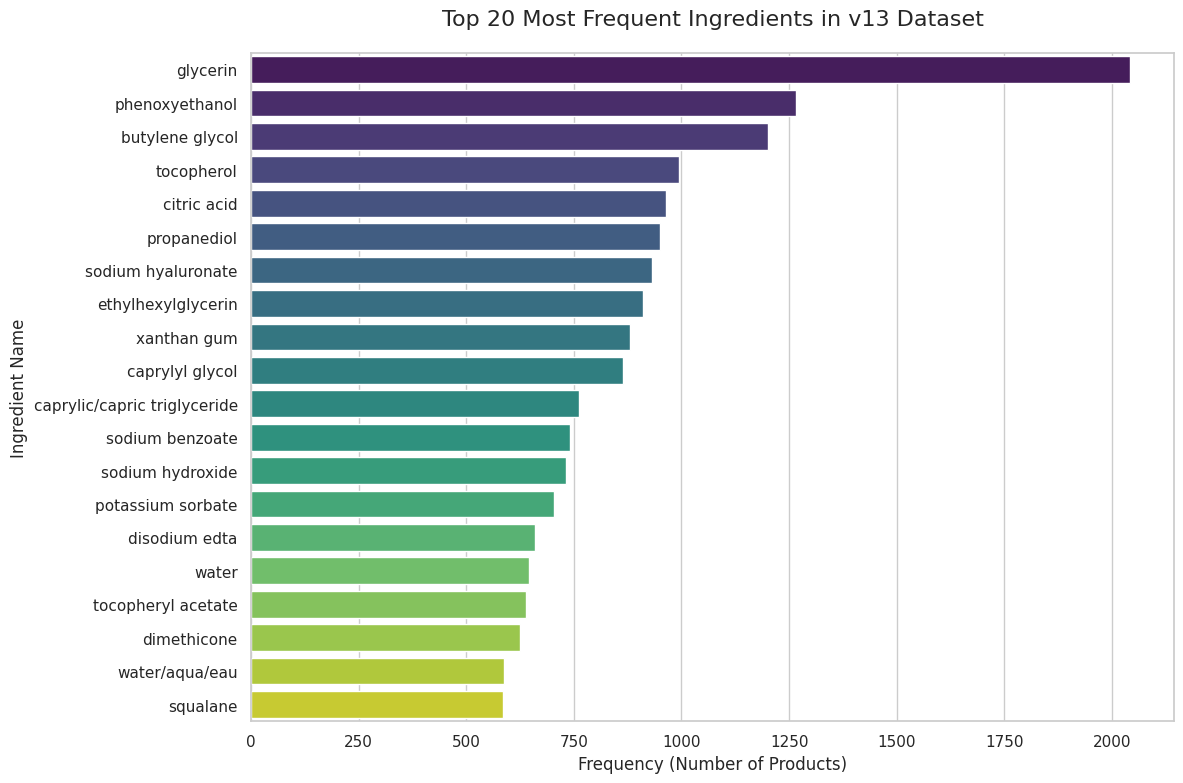

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Select the top 20 ingredients
top_20_ingredients = ingredient_counts.head(20)

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_20_ingredients,
    x='Total Frequency',
    y='Ingredient Name',
    hue='Ingredient Name',
    palette='viridis',
    legend=False
)

# Add labels and title
plt.title('Top 20 Most Frequent Ingredients in v13 Dataset', fontsize=16, pad=20)
plt.xlabel('Frequency (Number of Products)', fontsize=12)
plt.ylabel('Ingredient Name', fontsize=12)

plt.tight_layout()
plt.show()